# Modelo de Machine Learning — Titanic

## Objetivo

Nesta etapa, será construído um modelo de classificação para prever se um passageiro sobreviveu ao naufrágio do Titanic.

O arquivo `train.csv` será utilizado para treinar e validar o modelo, pois contém a variável-alvo `Survived`. Depois da avaliação, o modelo será treinado novamente com todos os registros disponíveis e utilizado para gerar previsões para o arquivo `test.csv`.


## Etapas do notebook

1. Carregamento das bases de treino e teste;
2. Criação de novas variáveis;
3. Seleção das variáveis explicativas e da variável-alvo;
4. Separação entre treino e validação;
5. Tratamento de valores ausentes e variáveis categóricas;
6. Treinamento de uma Regressão Logística;
7. Avaliação do modelo;
8. Validação cruzada;
9. Treinamento com todos os dados;
10. Geração do arquivo `submission.csv`.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    cross_val_score,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

## 1. Carregamento dos dados

O conjunto de treino contém a coluna `Survived`, enquanto o conjunto de teste não possui essa coluna. Portanto, não é possível medir diretamente o desempenho do modelo no `test.csv`.


In [2]:
train = pd.read_csv("../data/train.csv")
test = pd.read_csv("../data/test.csv")

print(f"Treino: {train.shape[0]} linhas e {train.shape[1]} colunas")
print(f"Teste: {test.shape[0]} linhas e {test.shape[1]} colunas")

Treino: 891 linhas e 12 colunas
Teste: 418 linhas e 11 colunas


In [3]:
train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
print("Colunas presentes apenas no treino:")
print(sorted(set(train.columns) - set(test.columns)))

Colunas presentes apenas no treino:
['Survived']


### Interpretação

A coluna `Survived` aparece apenas no conjunto de treino porque ela representa a resposta que o modelo deverá aprender a prever.


## 2. Engenharia de atributos

Serão criadas duas variáveis simples:

- `FamilySize`: quantidade total de pessoas da família a bordo, incluindo o próprio passageiro;
- `IsAlone`: indica se o passageiro viajava sozinho.


In [6]:
def criar_atributos(dados):
    dados = dados.copy()

    dados["FamilySize"] = (
        dados["SibSp"]
        + dados["Parch"]
        + 1
    )

    dados["IsAlone"] = (
        dados["FamilySize"] == 1
    ).astype(int)

    return dados


train_ml = criar_atributos(train)
test_ml = criar_atributos(test)

In [7]:
train_ml[
    ["SibSp", "Parch", "FamilySize", "IsAlone"]
].head()

,SibSp,Parch,FamilySize,IsAlone
0,1,0,2,0
1,1,0,2,0
2,0,0,1,1
3,1,0,2,0
4,0,0,1,1


## 3. Seleção das variáveis

Para o primeiro modelo, serão utilizadas variáveis que apresentaram relação com a sobrevivência durante a análise exploratória.

As colunas `PassengerId`, `Name`, `Ticket` e `Cabin` não serão utilizadas neste modelo inicial.


In [8]:
variaveis_numericas = [
    "Age",
    "SibSp",
    "Parch",
    "Fare",
    "FamilySize",
    "IsAlone"
]

variaveis_categoricas = [
    "Pclass",
    "Sex",
    "Embarked"
]

variaveis_modelo = (
    variaveis_numericas
    + variaveis_categoricas
)

X = train_ml[variaveis_modelo]
y = train_ml["Survived"]

X_test_kaggle = test_ml[variaveis_modelo]

In [9]:
print("Variáveis explicativas:")
print(variaveis_modelo)

print("\nDistribuição da variável-alvo:")
print(y.value_counts(normalize=True).mul(100).round(2))

Variáveis explicativas:
['Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'Pclass', 'Sex', 'Embarked']

Distribuição da variável-alvo:
Survived
0    61.62
1    38.38
Name: proportion, dtype: float64


## 4. Separação entre treino e validação

Uma parte do `train.csv` será reservada para validação local. Dessa forma, o modelo será avaliado em passageiros que não foram utilizados durante o treinamento.

O parâmetro `stratify=y` mantém proporções semelhantes de sobreviventes e não sobreviventes nos dois subconjuntos.


In [10]:
X_treino, X_validacao, y_treino, y_validacao = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Registros de treino: {len(X_treino)}")
print(f"Registros de validação: {len(X_validacao)}")

Registros de treino: 712
Registros de validação: 179


## 5. Pré-processamento

As variáveis numéricas e categóricas exigem tratamentos diferentes:

- valores ausentes numéricos serão preenchidos com a mediana;
- variáveis numéricas serão padronizadas;
- valores ausentes categóricos serão preenchidos com o valor mais frequente;
- categorias textuais serão transformadas em colunas numéricas por meio de One-Hot Encoding.

Todo o pré-processamento será reunido em um `Pipeline`, garantindo que os mesmos tratamentos sejam aplicados ao treino, à validação e ao conjunto de teste.


In [11]:
pipeline_numerico = Pipeline(
    steps=[
        (
            "preenchimento",
            SimpleImputer(strategy="median")
        ),
        (
            "padronizacao",
            StandardScaler()
        )
    ]
)

pipeline_categorico = Pipeline(
    steps=[
        (
            "preenchimento",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "codificacao",
            OneHotEncoder(handle_unknown="ignore")
        )
    ]
)

preprocessador = ColumnTransformer(
    transformers=[
        (
            "numericas",
            pipeline_numerico,
            variaveis_numericas
        ),
        (
            "categoricas",
            pipeline_categorico,
            variaveis_categoricas
        )
    ]
)

## 6. Criação e treinamento do modelo

A Regressão Logística será utilizada como modelo inicial. Apesar do nome, ela é um algoritmo de classificação adequado para prever resultados binários, como `0` ou `1`.


In [12]:
modelo = Pipeline(
    steps=[
        (
            "preprocessamento",
            preprocessador
        ),
        (
            "classificador",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

modelo.fit(
    X_treino,
    y_treino
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','SibSp','Parch',...,'Pclass','Sex','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

## 7. Avaliação na base de validação


In [13]:
previsoes_validacao = modelo.predict(
    X_validacao
)

acuracia = accuracy_score(
    y_validacao,
    previsoes_validacao
)

print(f"Acurácia na validação: {acuracia:.2%}")

Acurácia na validação: 81.56%


In [14]:
print(
    classification_report(
        y_validacao,
        previsoes_validacao,
        target_names=[
            "Não sobreviveu",
            "Sobreviveu"
        ]
    )
)

                precision    recall  f1-score   support

Não sobreviveu       0.82      0.90      0.86       110
    Sobreviveu       0.81      0.68      0.74        69

      accuracy                           0.82       179
     macro avg       0.81      0.79      0.80       179
  weighted avg       0.82      0.82      0.81       179



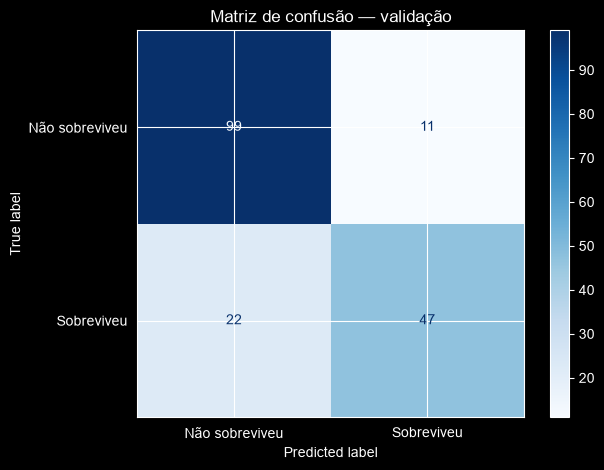

In [15]:
ConfusionMatrixDisplay.from_predictions(
    y_validacao,
    previsoes_validacao,
    display_labels=[
        "Não sobreviveu",
        "Sobreviveu"
    ],
    cmap="Blues"
)

plt.title("Matriz de confusão — validação")
plt.tight_layout()
plt.show()

### Como interpretar a avaliação

- **Acurácia:** proporção total de previsões corretas;
- **Precisão:** entre os passageiros previstos em uma classe, quantos realmente pertenciam a ela;
- **Recall:** entre os passageiros que realmente pertenciam a uma classe, quantos foram identificados;
- **F1-score:** equilíbrio entre precisão e recall;
- **Matriz de confusão:** mostra acertos e erros de cada classe.

A acurácia não deve ser analisada isoladamente. É importante observar se o modelo consegue identificar tanto sobreviventes quanto não sobreviventes.


## 8. Validação cruzada

A validação cruzada repete o treinamento e a avaliação em diferentes divisões dos dados. Isso fornece uma estimativa mais estável do desempenho do modelo do que uma única divisão.


In [16]:
resultados_validacao_cruzada = cross_val_score(
    modelo,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("Acurácias em cada divisão:")
print(resultados_validacao_cruzada.round(4))

print(
    "\nAcurácia média: "
    f"{resultados_validacao_cruzada.mean():.2%}"
)

print(
    "Desvio padrão: "
    f"{resultados_validacao_cruzada.std():.2%}"
)

Acurácias em cada divisão:
[0.7765 0.7978 0.7978 0.7809 0.8258]

Acurácia média: 79.58%
Desvio padrão: 1.73%


## 9. Treinamento final

Após a avaliação, o modelo será treinado novamente utilizando todos os registros do `train.csv`.


In [17]:
modelo.fit(
    X,
    y
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessamento', ...), ('classificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Age','SibSp','Parch',...,'Pclass','Sex','Embarked']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numericas', ...), ('categoricas', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``

## 10. Previsões para o conjunto de teste


In [18]:
previsoes_teste = modelo.predict(
    X_test_kaggle
)

previsoes_teste[:10]

array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0])

## 11. Criação do arquivo de submissão

O arquivo final deve possuir exatamente duas colunas:

- `PassengerId`;
- `Survived`.


In [19]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Survived": previsoes_teste.astype(int)
})

submission.head()

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,1


In [20]:
assert len(submission) == len(test)
assert list(submission.columns) == [
    "PassengerId",
    "Survived"
]
assert submission["Survived"].isin([0, 1]).all()
assert submission["PassengerId"].equals(
    test["PassengerId"]
)

print("Formato da submissão validado com sucesso.")

Formato da submissão validado com sucesso.


In [21]:
caminho_submission = "../submission.csv"

submission.to_csv(
    caminho_submission,
    index=False
)

print(
    "Arquivo criado em:",
    caminho_submission
)

Arquivo criado em: ../submission.csv


## 12. Conclusão

Foi construído um pipeline completo de classificação contendo:

- criação de atributos;
- tratamento de valores ausentes;
- transformação de variáveis categóricas;
- padronização de variáveis numéricas;
- treinamento de uma Regressão Logística;
- avaliação em uma base de validação;
- validação cruzada;
- geração de previsões para o `test.csv`;
- criação do arquivo `submission.csv`.

Como próximos passos, o desempenho poderá ser comparado com outros algoritmos, como Árvore de Decisão e Random Forest, além da criação de novos atributos a partir das colunas `Name`, `Ticket` e `Cabin`.
